# Modelo Multimodal con Transfer Learning (ImageNet)

Este cuaderno implementa la experimentación con el modelo **MTDE-Net** utilizando **Transfer Learning** basado en backbones convolucionales preentrenados en **ImageNet** (ResNet-18 y ResNet-50).

### Enfoque Científico del Experimento:
* Las imágenes térmicas son canal único (escala de grises), por lo que se expanden a 3 canales en la primera capa convolucional de manera implícita para conservar el 100% de los pesos preentrenados de ImageNet.
* Evaluamos tres configuraciones de entrenamiento:
  1. **ResNet-18 con Fine-tuning completo** (backbone preentrenado sintonizado con learning rate bajo).
  2. **ResNet-18 con Backbone Congelado** (usado puramente como extractor de características estáticas).
  3. **ResNet-50 con Fine-tuning completo** (backbone de mayor capacidad no lineal).

Al final, se comparan las métricas obtenidas con las del MTDE-Net original sin preentrenar.

In [1]:
import sys
import random
from pathlib import Path

# Añadir el directorio raíz al path de Python para permitir importaciones correctas
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

from src.models.mtde_net_tl import MTDE_Net_TL
from src.loaders.mtde_net_loader import MultimodalThermalDataset
from src.utils import SqrtScaledMSELoss, eval_mtde_net_metrics, split_by_sequence, plot_learning_curves, plot_prediction_calibration, plot_error_by_time_window, plot_learning_curves, plot_prediction_calibration, plot_error_by_time_window

### 1. Semilla Global y Reproducibilidad

In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

### 2. Carga del Dataset y Partición Estricta por Secuencias

In [3]:
dev = "cuda" if torch.cuda.is_available() else "cpu"
time_scale = 30.0

train_ds_full = MultimodalThermalDataset(
    metadata_csv="../processed_data/metadata_train.csv", 
    is_train=True, 
    min_time_s=0.0,
    time_scale=time_scale
)
val_ds_full = MultimodalThermalDataset(
    metadata_csv="../processed_data/metadata_train.csv", 
    is_train=False, 
    min_time_s=0.0,
    time_scale=time_scale
)
train_ds_full.root = Path("../processed_data")
val_ds_full.root = Path("../processed_data")

t_idx, v_idx = split_by_sequence(train_ds_full.df)
print(f"Dataset cargado exitosamente. Particiones: {len(t_idx)} train / {len(v_idx)} val")

Dataset cargado exitosamente. Particiones: 1111 train / 329 val


### 3. Función Genérica de Entrenamiento y Evaluación

In [4]:
def train_and_evaluate(backbone_name, pretrained, freeze_backbone, lr, epochs=30, batch_size=16, patience=8):
    set_seed(42)
    
    train_loader = DataLoader(Subset(train_ds_full, t_idx), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(Subset(val_ds_full, v_idx), batch_size=batch_size)
    
    # Instanciar el modelo con transfer learning
    model = MTDE_Net_TL(
        backbone_name=backbone_name,
        pretrained=pretrained,
        freeze_backbone=freeze_backbone,
        tabular_dim=4,
        dropout=0.2
    ).to(dev)
    
    crit = SqrtScaledMSELoss(scale=time_scale)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    
    best_mae = float("inf")
    best_metrics = None
    patience_counter = 0
    
    # Historial para graficar
    history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}
    
    print(f"\n>>> Entrenando {backbone_name.upper()} | Pretrained: {pretrained} | Freeze: {freeze_backbone} | lr: {lr}")
    
    for ep in range(1, epochs + 1):
        model.train()
        train_loss, n = 0.0, 0
        for x_img, x_tab, y in train_loader:
            x_img, x_tab, y = x_img.to(dev), x_tab.to(dev), y.to(dev)
            opt.zero_grad(set_to_none=True)
            loss = crit(model(x_img, x_tab), y)
            loss.backward()
            opt.step()
            train_loss += loss.item() * len(y)
            n += len(y)
            
        train_loss /= n
        
        # Calcular pérdida de validación para el historial
        model.eval()
        val_loss = 0.0
        val_n = 0
        with torch.no_grad():
            for val_x_img, val_x_tab, val_y in val_loader:
                val_x_img, val_x_tab, val_y = val_x_img.to(dev), val_x_tab.to(dev), val_y.to(dev)
                loss = crit(model(val_x_img, val_x_tab), val_y)
                val_loss += loss.item() * len(val_y)
                val_n += len(val_y)
        val_loss /= val_n
        
        # Evaluar en validación
        metrics = eval_mtde_net_metrics(model, val_loader, dev, scale=time_scale)
        train_m = eval_mtde_net_metrics(model, train_loader, dev, scale=time_scale)
        v_mae = metrics["mae"]
        star = ""
        if v_mae < best_mae:
            best_mae = v_mae
            best_metrics = metrics
            patience_counter = 0
            star = " *"
            try:
                dest_path = Path(f"../MTDE_Net_TL_{backbone_name}_{'congelado' if freeze_backbone else 'finetuned'}.pt")
                if dest_path.exists(): dest_path.unlink(missing_ok=True)
                torch.save(model.state_dict(), dest_path)
            except Exception:
                alt_path = Path(f"../MTDE_Net_TL_{backbone_name}_{'congelado' if freeze_backbone else 'finetuned'}_alt.pt")
                if alt_path.exists(): alt_path.unlink(missing_ok=True)
                torch.save(model.state_dict(), alt_path)
                print(f"Nota: Se guardó en '{alt_path.name}' debido a un bloqueo de Windows.")
        else:
            patience_counter += 1
            
        # Guardar en el historial
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_mae"].append(train_m["mae"])
        history["val_mae"].append(v_mae)
            
        print(f"Ep {ep:03d} | Loss: {train_loss:.4f} | ValMAE: {v_mae:.2f}s | RMSE: {metrics['rmse']:.2f}s | R2: {metrics['r2']:.4f} | MAPE: {metrics['mape']:.2f}% | Acc60: {metrics['acc60']:.2f}% | Acc120: {metrics['acc120']:.2f}%{star}")
        
        if patience_counter >= patience:
            print(f"Early stop alcanzado. Mejor Val MAE: {best_mae:.2f}s")
            break
            
    # Al final del entrenamiento, graficar todo usando nuestras utilidades
    print(f"\n=== GRÁFICOS DE APRENDIZAJE Y CALIBRACIÓN - {backbone_name.upper()} ({'CONGELADO' if freeze_backbone else 'FINE-TUNED'}) ===")
    plot_learning_curves(history)
    
    # Cargar mejor modelo y graficar calibración/error
    chk_path = Path(f"../MTDE_Net_TL_{backbone_name}_{'congelado' if freeze_backbone else 'finetuned'}.pt")
    alt_path = Path(f"../MTDE_Net_TL_{backbone_name}_{'congelado' if freeze_backbone else 'finetuned'}_alt.pt")
    if alt_path.exists() and (not chk_path.exists() or alt_path.stat().st_mtime > chk_path.stat().st_mtime):
        model.load_state_dict(torch.load(alt_path, map_location=dev))
    else:
        model.load_state_dict(torch.load(chk_path, map_location=dev))
    model.eval()
    
    y_true_list = []
    y_pred_list = []
    with torch.no_grad():
        for x_img, x_tab, val_y in val_loader:
            x_img, x_tab, val_y = x_img.to(dev), x_tab.to(dev), val_y.to(dev)
            preds = model(x_img, x_tab)
            y_true_list.extend((val_y.cpu().numpy() * time_scale).tolist())
            y_pred_list.extend((preds.cpu().numpy() * time_scale).tolist())
            
    y_true = np.array(y_true_list)
    y_pred = np.array(y_pred_list)
    
    plot_prediction_calibration(y_true, y_pred, model_name=f"ResNet-{backbone_name[6:]} TL")
    plot_error_by_time_window(y_true, y_pred, model_name=f"ResNet-{backbone_name[6:]} TL")
    
    return best_metrics

### 4. Experimento 1: ResNet-18 Preentrenado + Fine-tuning completo


>>> Entrenando RESNET18 | Pretrained: True | Freeze: False | lr: 0.0002
Ep 001 | Loss: 0.0484 | ValMAE: 104.77s | RMSE: 134.95s | R2: 0.3300 | MAPE: 64.55% | Acc60: 32.52% | Acc120: 72.64% *
Ep 002 | Loss: 0.0279 | ValMAE: 98.10s | RMSE: 123.41s | R2: 0.4397 | MAPE: 61.95% | Acc60: 35.87% | Acc120: 72.04% *
Ep 003 | Loss: 0.0189 | ValMAE: 80.59s | RMSE: 103.90s | R2: 0.6029 | MAPE: 53.94% | Acc60: 50.46% | Acc120: 79.64% *
Ep 004 | Loss: 0.0133 | ValMAE: 65.58s | RMSE: 87.99s | R2: 0.7152 | MAPE: 40.60% | Acc60: 57.75% | Acc120: 84.50% *
Ep 005 | Loss: 0.0122 | ValMAE: 63.04s | RMSE: 83.74s | R2: 0.7420 | MAPE: 45.35% | Acc60: 60.18% | Acc120: 86.63% *
Ep 006 | Loss: 0.0094 | ValMAE: 42.68s | RMSE: 65.02s | R2: 0.8445 | MAPE: 30.63% | Acc60: 74.77% | Acc120: 91.79% *
Ep 007 | Loss: 0.0074 | ValMAE: 37.97s | RMSE: 56.56s | R2: 0.8823 | MAPE: 31.75% | Acc60: 82.67% | Acc120: 92.40% *
Ep 008 | Loss: 0.0060 | ValMAE: 47.73s | RMSE: 67.53s | R2: 0.8322 | MAPE: 36.93% | Acc60: 71.73% | Acc1

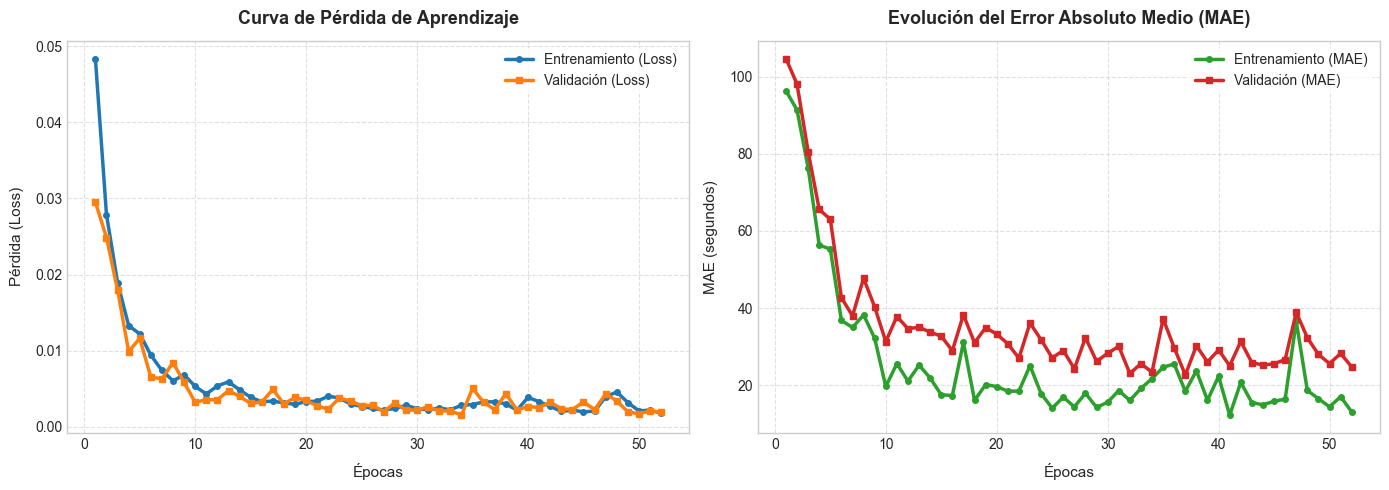

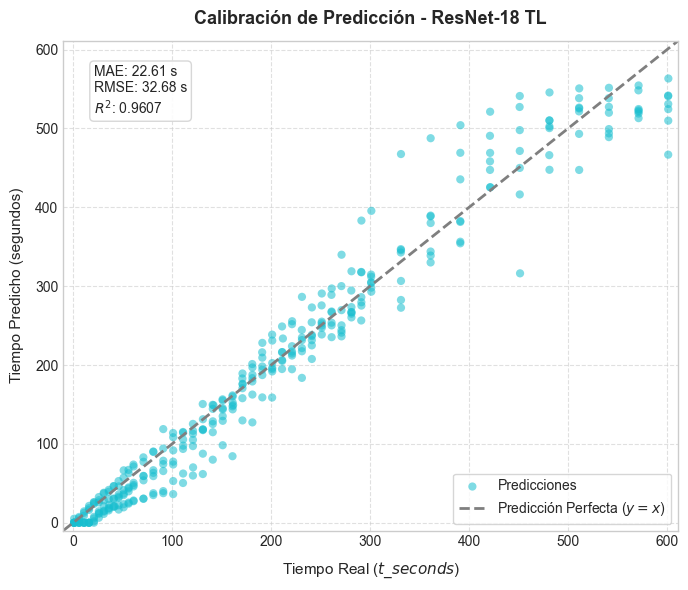

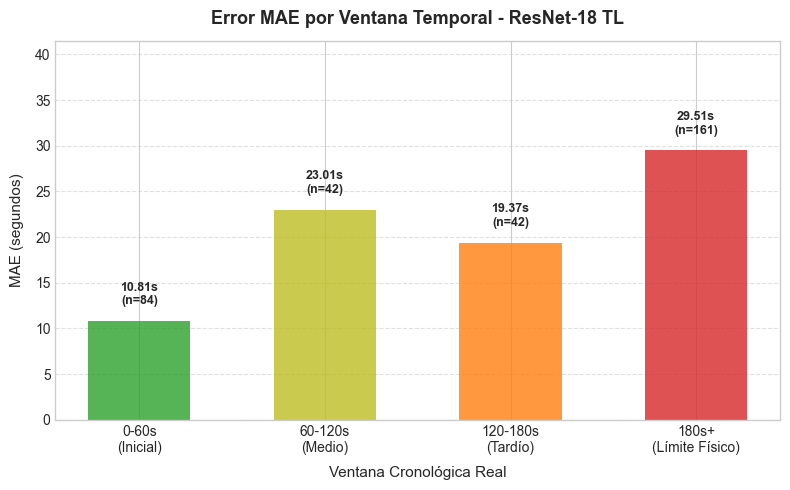

In [5]:
# Fine-tuning completo con una lr baja de 2e-4
m_r18_ft = train_and_evaluate(
    backbone_name="resnet18", 
    pretrained=True, 
    freeze_backbone=False, 
    lr=2e-4, 
    epochs=120, 
    batch_size=16,
    patience=15
)

### 5. Experimento 2: ResNet-18 Congelado (Feature Extractor estático)


>>> Entrenando RESNET18 | Pretrained: True | Freeze: True | lr: 0.0005
Ep 001 | Loss: 0.0569 | ValMAE: 114.74s | RMSE: 165.83s | R2: -0.0117 | MAPE: 64.74% | Acc60: 48.02% | Acc120: 67.78% *
Ep 002 | Loss: 0.0245 | ValMAE: 86.35s | RMSE: 130.70s | R2: 0.3716 | MAPE: 63.47% | Acc60: 55.32% | Acc120: 78.12% *
Ep 003 | Loss: 0.0134 | ValMAE: 72.68s | RMSE: 110.98s | R2: 0.5469 | MAPE: 74.34% | Acc60: 62.61% | Acc120: 82.98% *
Ep 004 | Loss: 0.0109 | ValMAE: 68.27s | RMSE: 103.78s | R2: 0.6038 | MAPE: 81.65% | Acc60: 64.44% | Acc120: 83.59% *
Ep 005 | Loss: 0.0083 | ValMAE: 70.75s | RMSE: 106.02s | R2: 0.5865 | MAPE: 63.01% | Acc60: 62.61% | Acc120: 80.24%
Ep 006 | Loss: 0.0094 | ValMAE: 61.79s | RMSE: 90.38s | R2: 0.6995 | MAPE: 77.78% | Acc60: 65.05% | Acc120: 83.28% *
Ep 007 | Loss: 0.0090 | ValMAE: 61.72s | RMSE: 94.34s | R2: 0.6726 | MAPE: 76.92% | Acc60: 67.78% | Acc120: 84.19% *
Ep 008 | Loss: 0.0083 | ValMAE: 59.02s | RMSE: 89.62s | R2: 0.7046 | MAPE: 81.18% | Acc60: 68.09% | Acc1

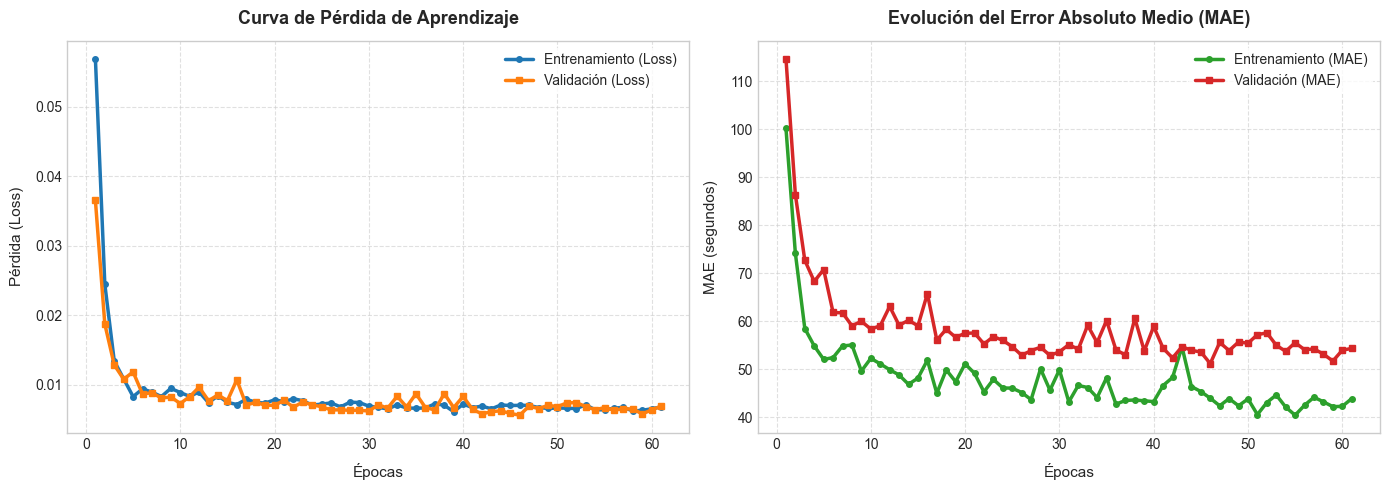

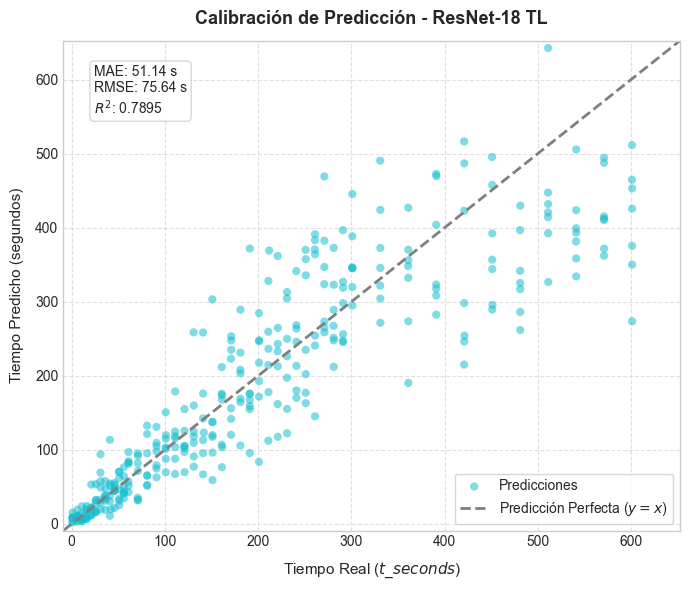

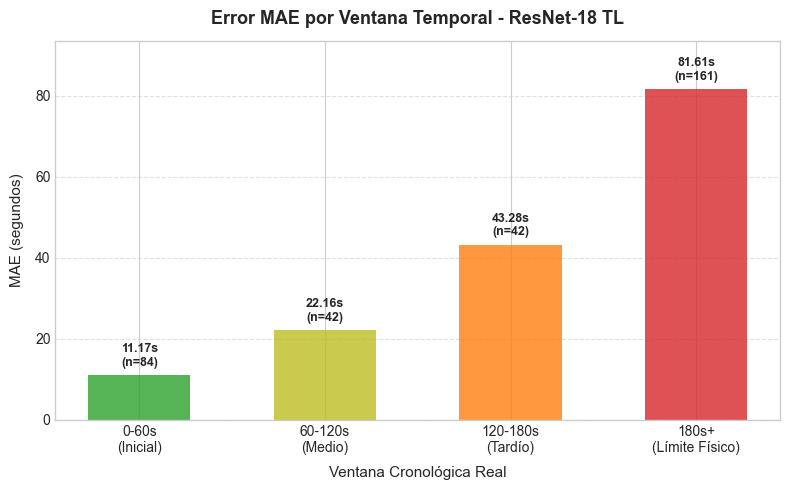

In [6]:
# Backbone congelado, se puede usar una lr un poco mayor (5e-4) para el cabezal
m_r18_frozen = train_and_evaluate(
    backbone_name="resnet18", 
    pretrained=True, 
    freeze_backbone=True, 
    lr=5e-4, 
    epochs=120, 
    batch_size=16,
    patience=15
)

### 6. Experimento 3: ResNet-50 Preentrenado + Fine-tuning completo


>>> Entrenando RESNET50 | Pretrained: True | Freeze: False | lr: 0.0001
Ep 001 | Loss: 0.0635 | ValMAE: 132.84s | RMSE: 181.90s | R2: -0.2173 | MAPE: 70.17% | Acc60: 37.08% | Acc120: 62.31% *
Ep 002 | Loss: 0.0411 | ValMAE: 121.79s | RMSE: 160.54s | R2: 0.0519 | MAPE: 70.24% | Acc60: 29.79% | Acc120: 66.26% *
Ep 003 | Loss: 0.0336 | ValMAE: 109.88s | RMSE: 143.79s | R2: 0.2394 | MAPE: 65.57% | Acc60: 33.43% | Acc120: 70.82% *
Ep 004 | Loss: 0.0271 | ValMAE: 105.12s | RMSE: 135.01s | R2: 0.3294 | MAPE: 64.62% | Acc60: 34.65% | Acc120: 71.12% *
Ep 005 | Loss: 0.0228 | ValMAE: 99.80s | RMSE: 135.17s | R2: 0.3278 | MAPE: 59.40% | Acc60: 42.86% | Acc120: 73.86% *
Ep 006 | Loss: 0.0189 | ValMAE: 79.66s | RMSE: 105.97s | R2: 0.5868 | MAPE: 52.85% | Acc60: 52.28% | Acc120: 82.07% *
Ep 007 | Loss: 0.0165 | ValMAE: 52.77s | RMSE: 75.12s | R2: 0.7924 | MAPE: 37.09% | Acc60: 72.34% | Acc120: 88.15% *
Ep 008 | Loss: 0.0131 | ValMAE: 56.98s | RMSE: 75.82s | R2: 0.7885 | MAPE: 44.03% | Acc60: 70.52%

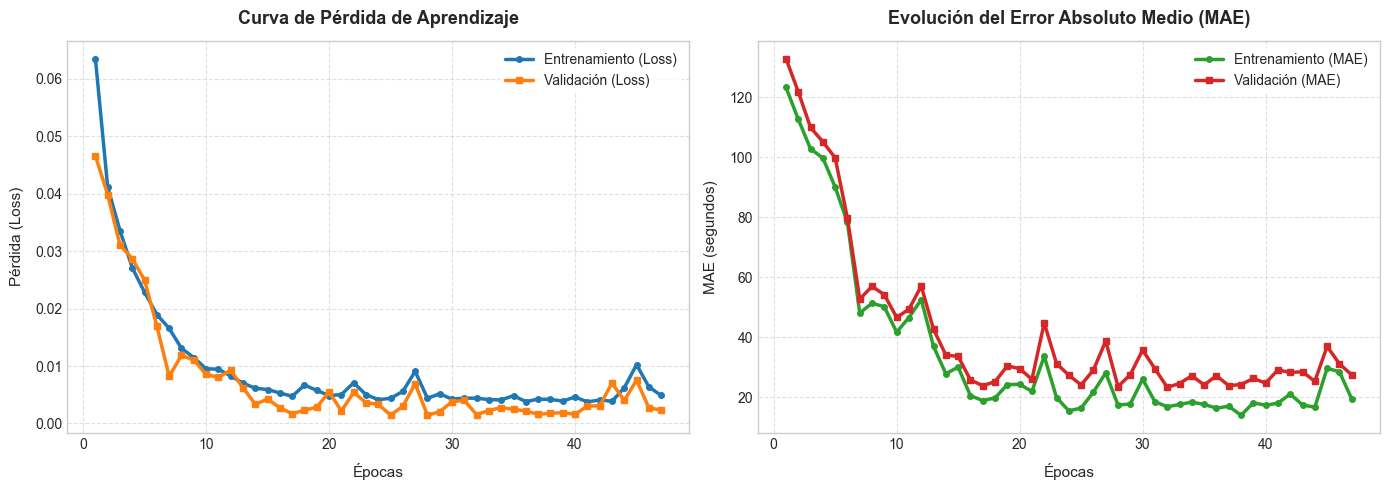

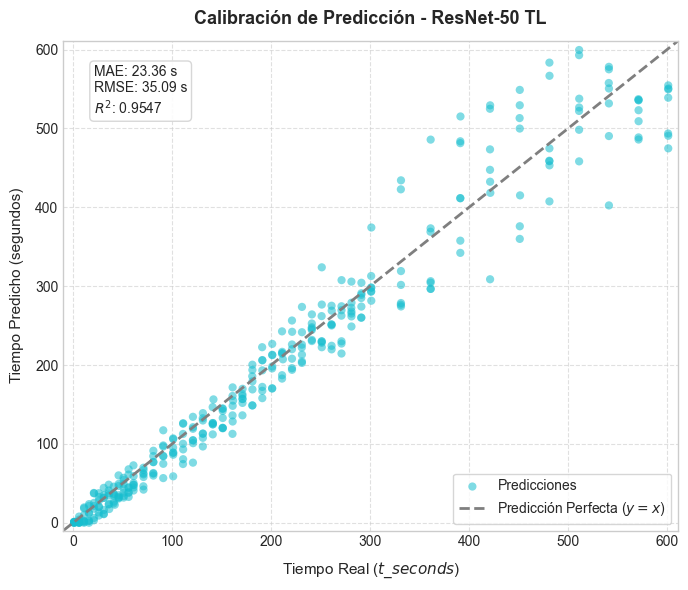

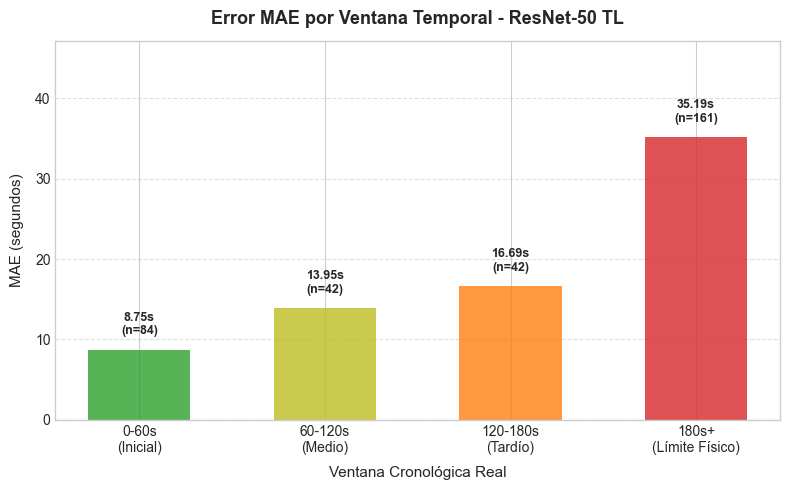

In [7]:
# ResNet-50 es más expresivo y denso. Usamos una lr controlada de 1e-4
m_r50_ft = train_and_evaluate(
    backbone_name="resnet50", 
    pretrained=True, 
    freeze_backbone=False, 
    lr=1e-4, 
    epochs=120, 
    batch_size=16,
    patience=15
)

### 7. Resumen y Comparación de Resultados Experimentales

In [8]:
results_data = []

if m_r18_ft:
    results_data.append({
        "Configuración": "ResNet-18 Fine-tuned (ImageNet)",
        "MAE (s)": f"{m_r18_ft['mae']:.2f} s",
        "RMSE (s)": f"{m_r18_ft['rmse']:.2f} s",
        "R²": f"{m_r18_ft['r2']:.4f}",
        "MAPE (%)": f"{m_r18_ft['mape']:.2f} %",
        "Acc@60s (%)": f"{m_r18_ft['acc60']:.2f} %",
        "Acc@120s (%)": f"{m_r18_ft['acc120']:.2f} %"
    })
if m_r18_frozen:
    results_data.append({
        "Configuración": "ResNet-18 Frozen (FE)",
        "MAE (s)": f"{m_r18_frozen['mae']:.2f} s",
        "RMSE (s)": f"{m_r18_frozen['rmse']:.2f} s",
        "R²": f"{m_r18_frozen['r2']:.4f}",
        "MAPE (%)": f"{m_r18_frozen['mape']:.2f} %",
        "Acc@60s (%)": f"{m_r18_frozen['acc60']:.2f} %",
        "Acc@120s (%)": f"{m_r18_frozen['acc120']:.2f} %"
    })
if m_r50_ft:
    results_data.append({
        "Configuración": "ResNet-50 Fine-tuned (ImageNet)",
        "MAE (s)": f"{m_r50_ft['mae']:.2f} s",
        "RMSE (s)": f"{m_r50_ft['rmse']:.2f} s",
        "R²": f"{m_r50_ft['r2']:.4f}",
        "MAPE (%)": f"{m_r50_ft['mape']:.2f} %",
        "Acc@60s (%)": f"{m_r50_ft['acc60']:.2f} %",
        "Acc@120s (%)": f"{m_r50_ft['acc120']:.2f} %"
    })

df_res = pd.DataFrame(results_data)
print("\n=== RESUMEN COMPARATIVO DE TRANSFER LEARNING ===")
display(df_res)


=== RESUMEN COMPARATIVO DE TRANSFER LEARNING ===


,Configuración,MAE (s),RMSE (s),R²,MAPE (%),Acc@60s (%),Acc@120s (%)
0,ResNet-18 Fine-tuned (ImageNet),22.61 s,32.68 s,0.9607,22.95 %,92.40 %,98.78 %
1,ResNet-18 Frozen (FE),51.14 s,75.64 s,0.7895,43.16 %,69.00 %,87.84 %
2,ResNet-50 Fine-tuned (ImageNet),23.36 s,35.09 s,0.9547,18.86 %,90.58 %,98.78 %
